<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/images/IDSNlogo.png" width="300" alt="cognitiveclass.ai logo">
</center>

# **Adaptive Boosting (AdaBoost) for classification**


## **Boosting**

Boosting is an ensemble method that builds many simple models one after another. Each new model tries to improve the mistakes made by the previous models.

This is different from **Bagging**, where many models are trained independently on different bootstrap samples and then combined. Bagging mainly reduces variance, while boosting mainly reduces bias by training models sequentially.

Because later models focus on difficult training samples, boosting can become very accurate. However, it can also overfit if too many models are added or if the base models are too complex.

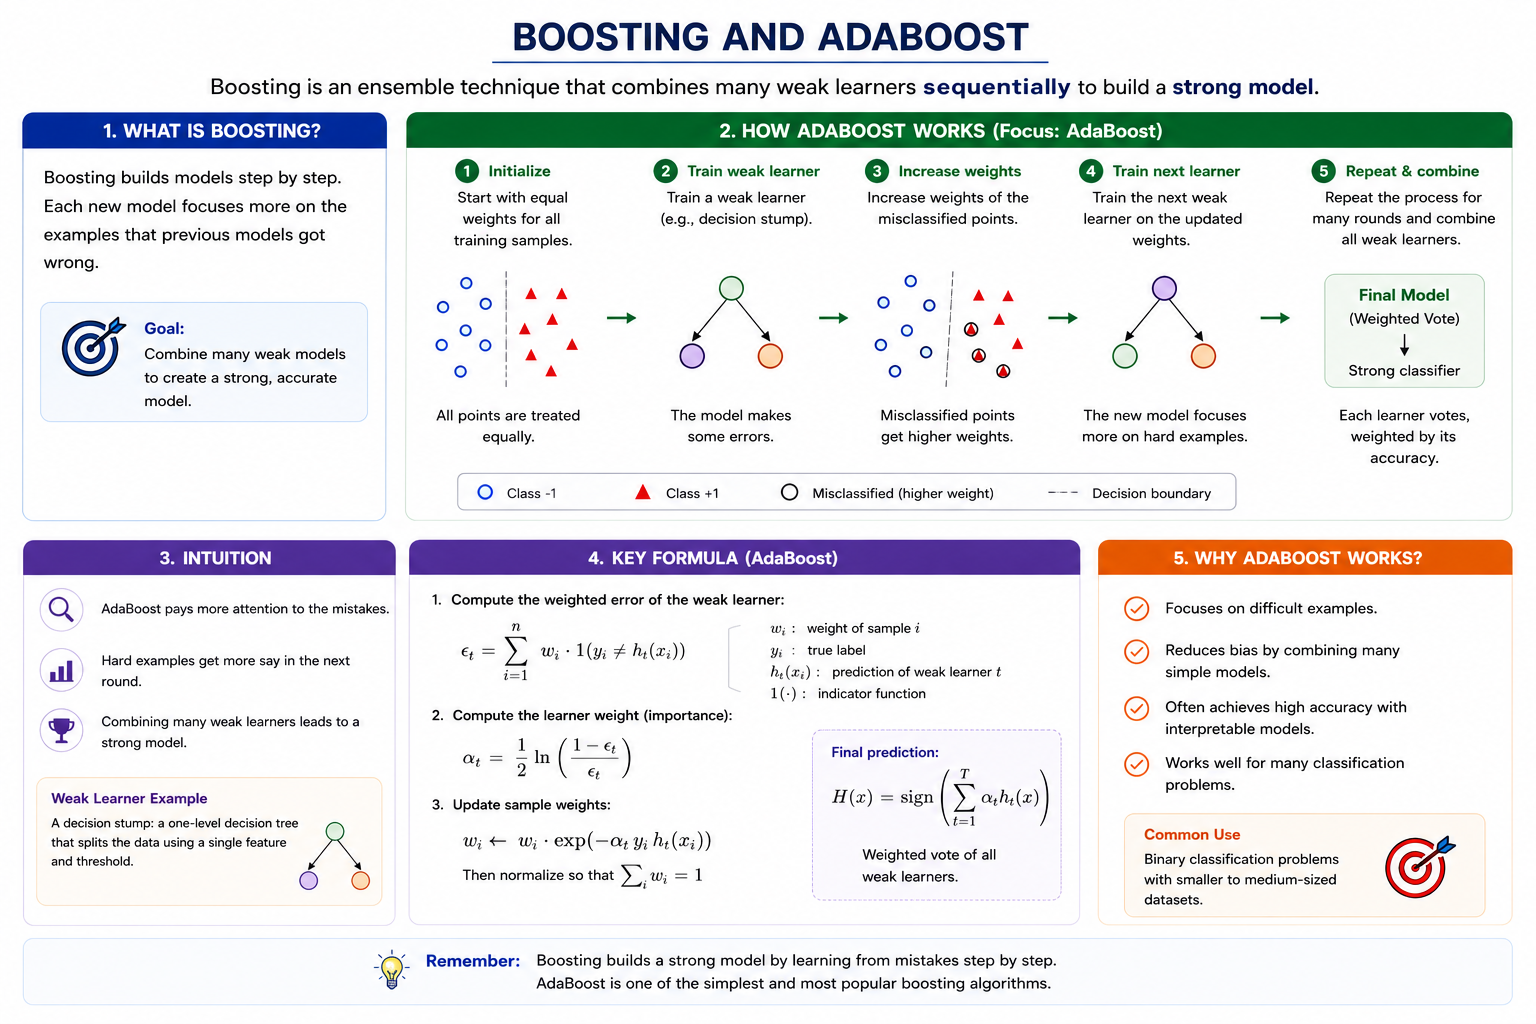

## **AdaBoost**

**AdaBoost**, short for **Adaptive Boosting**, is a popular boosting algorithm for classification. It usually uses weak learners, such as shallow decision trees. A weak learner is a model that performs only slightly better than random guessing.

AdaBoost trains weak learners in rounds. At the start, all training samples have equal weight. After each round, misclassified samples receive more weight, so the next weak learner focuses more on them.

The weighted error of weak learner $h_t(x)$ is:

$$
err_t = \sum_{i=1}^{n} w_i I(y_i \neq h_t(x_i))
$$

Here, $w_i$ is the weight of training sample $i$, and $I(y_i \neq h_t(x_i))$ equals 1 if the sample is misclassified and 0 otherwise.

AdaBoost gives better weak learners larger model weights:

$$
\alpha_t = \frac{1}{2}\ln\left(\frac{1 - err_t}{err_t}\right)
$$

Then AdaBoost updates the sample weights:

$$
w_i \leftarrow w_i \exp(-\alpha_t y_i h_t(x_i))
$$

In this formula, misclassified samples receive more weight, and correctly classified samples receive less weight. After updating, the weights are normalized so they sum to 1.


After all rounds, AdaBoost combines the weak learners using a weighted vote:

$$
H(x) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t h_t(x)\right)
$$

Here, $h_t(x)$ is weak learner $t$, $\alpha_t$ is that learner's weight, and $T$ is the total number of weak learners.

AdaBoost can also be viewed as minimizing this exponential loss:

$$
L = \sum_{i=1}^{n} \exp(-y_i F(x_i))
$$

The main idea is simple: difficult samples get more attention in later rounds, and more accurate weak learners get more influence in the final prediction.


## **Objectives**

A telecommunications company wants to understand why some customers are leaving its land-line service for cable competitors. We will use a telecommunications dataset to predict **customer churn**. 

*   Explain the difference between boosting and bagging
*   Understand how AdaBoost combines weak classifiers
*   Apply AdaBoost
*   Tune important AdaBoost hyperparameters

## **Workflow**
### **Setup**

Let's first import the required libraries:


In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.3 numpy==1.21.2 ipywidgets==7.4.2 scipy==7.4.2 tqdm==4.62.3 matplotlib==3.5.0 seaborn==0.9.0
# Note: If your environment doesn't support "!mamba install", use "!pip install"

In [2]:
import warnings

import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn import metrics, preprocessing
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.svm import SVC
from tqdm import tqdm

rs = 0


Ignore error warnings


In [3]:
import warnings
warnings.filterwarnings('ignore')

This function will calculate the accuracy of the training and testing data given a model.


In [4]:
def get_accuracy(X_train, X_test, y_train, y_test, model):
    return  {"test Accuracy":metrics.accuracy_score(y_test, model.predict(X_test)),"train Accuracy": metrics.accuracy_score(y_train, model.predict(X_train))}

This function calculates the average accuracy of differnt learning rates on training and test data


In [5]:
def get_accuracy_bag(X,y,title,times=20,xlabel='Number Estimators',Learning_rate_=[0.2,0.4,0.6,1]):

    lines_array=['solid','--', '-.', ':']

    N_estimators=[n for n in range(1,100)]
    
    times=20
    train_acc=np.zeros((times,len(Learning_rate_),len(N_estimators)))
    test_acc=np.zeros((times,len(Learning_rate_),len(N_estimators)))


    #Iterate through different number of Learning rate  and average out the results  
    for n in tqdm(range(times)):
        X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, stratify=y)
        for n_estimators in N_estimators:
            for j,lr in enumerate(Learning_rate_):


                model = AdaBoostClassifier(n_estimators=n_estimators+1,random_state=0,learning_rate=lr)


                model.fit(X_train,y_train)



                Accuracy=get_accuracy(X_train, X_test, y_train, y_test,  model)



                train_acc[n,j,n_estimators-1]=Accuracy['train Accuracy']
                test_acc[n,j,n_estimators-1]=Accuracy['test Accuracy']




    fig, ax1 = plt.subplots()
    mean_test=test_acc.mean(axis=0)
    mean_train=train_acc.mean(axis=0)
    ax2 = ax1.twinx()

    for j,(lr,line) in enumerate(zip(Learning_rate_,lines_array)): 

        ax1.plot(mean_train[j,:],linestyle = line,color='b',label="Learning rate "+str(lr))
        ax2.plot(mean_test[j,:],linestyle = line, color='r',label=str(lr))

    ax1.set_ylabel('Training accuracy',color='b')
    ax1.set_xlabel('No of estimators')
    ax1.legend()
    ax2.set_ylabel('Testing accuracy', color='r')
    ax2.legend()
    plt.show()

### **Customer Data Example**

The same customer churn dataset is used for the tree-based methods in notebooks 3.5.1 to 3.5.4.


Load Data From CSV File


In [6]:
churn_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv")

churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


#### **Data pre-processing and selection**


Let's select some features for the modeling. Also, we change the target data type to be an integer, as it is a requirement by the skitlearn algorithm:


In [7]:
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'callcard', 'wireless','churn']]
churn_df['churn'] = churn_df['churn'].astype('int')
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0


#### **Select Variables at Random**


Like Bagging, RF uses an independent bootstrap sample from the training data. In addition, we select $m$ variables at random out of all $M$ possible
variables. Let's do an example.


In [8]:
X=churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']]

there are 7 features


#### **Train/Test dataset**

Let's define X, and y for our dataset:


In [9]:
y = churn_df['churn']
y.head()

0    1
1    1
2    0
3    0
4    0
Name: churn, dtype: int64

We split our dataset into train and test set:


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=1, stratify=y)
print ('Train set', X_train.shape,  y_train.shape)
print ('Test set', X_test.shape,  y_test.shape)

Train set (140, 7) (140,)
Test set (60, 7) (60,)


#### **AdaBoost**


We can import the AdaBoost Classifier in Sklearn


In [11]:
from sklearn.ensemble import AdaBoostClassifier

The parameter <code>n_estimatorsint</code> is the maximum number of classifiers (default=50) at which boosting is stopped. If the results are perfect, the training procedure is stopped early.


In [12]:
n_estimators=5
random_state=0

We can create a <code>AdaBoostClassifier</code> object.


In [13]:
model = AdaBoostClassifier(n_estimators=n_estimators,random_state=random_state)

When AdaBoost uses 5 weak learners and each weak learner outputs either -1 or 1, the classifier can be written as:


$H(x) = 	ext{sign}(  \alpha_1 h_1(x)+ \alpha_2 h_2(x)+ \alpha_3 h_3(x)+ \alpha_4 h_4(x)+ \alpha_5 h_5(x) )$


We can fit the object finding all the $\alpha_t$ $h_t(x)$ and then make a prediction:


In [14]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred 

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

We can find the training and testing accuracy:


In [15]:
print(get_accuracy(X_train, X_test, y_train, y_test,  model))

{'test Accuracy': 0.7166666666666667, 'train Accuracy': 0.7571428571428571}


We see the base model is a Decision Tree. Since it only has one layer, it’s called a stump:


In [16]:
model.estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


We can output a list of the weak classifiers: $h_1(x), h_2(x), h_3(x),h_4(x)$ and $h_5(x)$


In [17]:
model.estimators_

[DecisionTreeClassifier(max_depth=1, random_state=209652396),
 DecisionTreeClassifier(max_depth=1, random_state=398764591),
 DecisionTreeClassifier(max_depth=1, random_state=924231285),
 DecisionTreeClassifier(max_depth=1, random_state=1478610112),
 DecisionTreeClassifier(max_depth=1, random_state=441365315)]

We see the weak classifiers do not perform as well:


In [18]:
[ ("for weak classifiers {} the we get ".format(i+1),get_accuracy(X_train, X_test, y_train, y_test,  weak_classifiers)) for i,weak_classifiers in enumerate(model.estimators_)]

[('for weak classifiers 1 the we get ',
  {'test Accuracy': 0.7166666666666667, 'train Accuracy': 0.7071428571428572}),
 ('for weak classifiers 2 the we get ',
  {'test Accuracy': 0.55, 'train Accuracy': 0.6428571428571429}),
 ('for weak classifiers 3 the we get ',
  {'test Accuracy': 0.7333333333333333, 'train Accuracy': 0.75}),
 ('for weak classifiers 4 the we get ',
  {'test Accuracy': 0.6166666666666667, 'train Accuracy': 0.6642857142857143}),
 ('for weak classifiers 5 the we get ',
  {'test Accuracy': 0.7166666666666667, 'train Accuracy': 0.7071428571428572})]

We can increase the number of weak classifiers:


In [19]:
n_estimators=100
random_state=0

and then fit the model


In [20]:
model = AdaBoostClassifier(n_estimators=n_estimators,random_state=random_state)
model.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = model.predict(X_test)

We obtain the  training and testing accuracy:


In [21]:
print(get_accuracy(X_train, X_test, y_train, y_test, model))

{'test Accuracy': 0.7, 'train Accuracy': 0.8714285714285714}


#### **Evaluation**

Evaluate the AdaBoost churn model using a confusion matrix, ROC curve, and precision-recall curve.


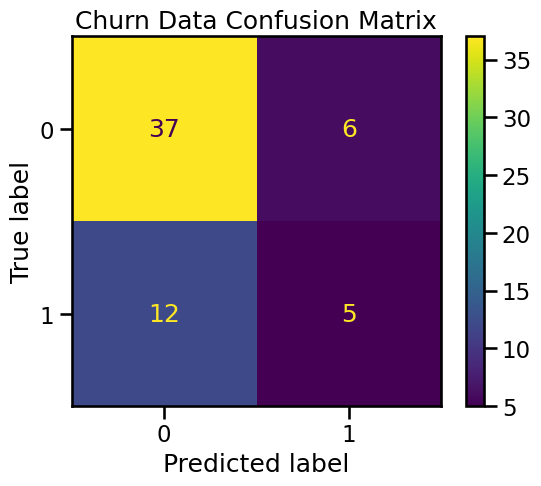

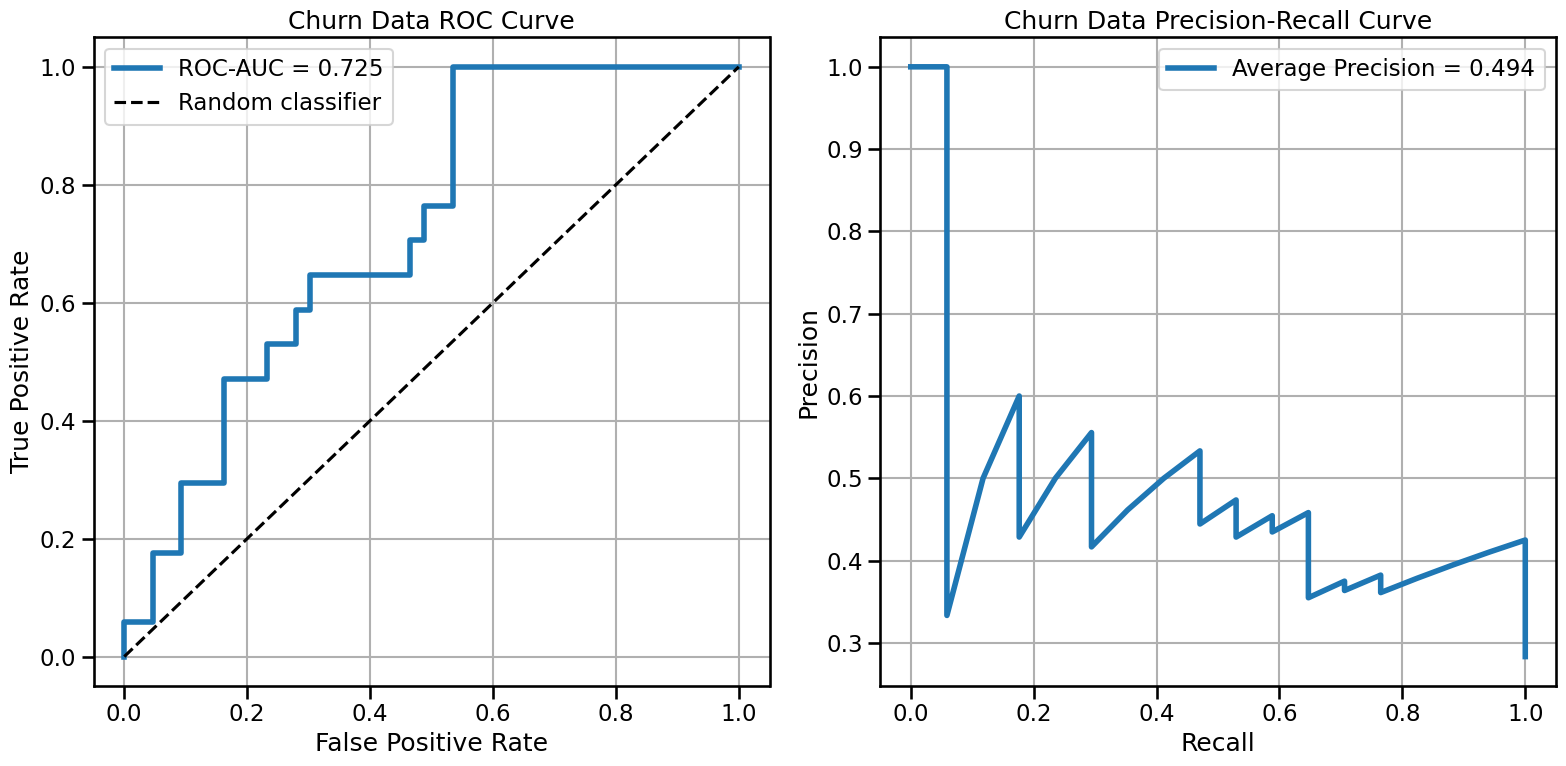

In [22]:
ada_churn = model
y_pred = ada_churn.predict(X_test)

sns.set_context('talk')
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ada_churn.classes_)
disp.plot()
plt.title('Churn Data Confusion Matrix')
plt.show()

# ROC and precision-recall curves for class 1.
y_score = ada_churn.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

fpr, tpr, _ = metrics.roc_curve(y_test, y_score)
roc_auc = metrics.roc_auc_score(y_test, y_score)
axes[0].plot(fpr, tpr, linewidth=4, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='black', label='Random classifier')
axes[0].set(title='Churn Data ROC Curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[0].legend()
axes[0].grid(True)

precision, recall, _ = metrics.precision_recall_curve(y_test, y_score)
avg_precision = metrics.average_precision_score(y_test, y_score)
axes[1].plot(recall, precision, linewidth=4, label=f'Average Precision = {avg_precision:.3f}')
axes[1].set(title='Churn Data Precision-Recall Curve', xlabel='Recall', ylabel='Precision')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


**Findings:**

The AdaBoost churn model reaches **0.70 test accuracy** and **0.871 training accuracy**. The training score is higher than the test score, so the model still has some overfitting. In the confusion matrix, the model correctly predicts many non-churn customers, but it only identifies **5 of the 17 churn customers**. This means churn recall is low, so the model may miss many customers who are likely to leave.


#### **Feature Importance**

Plot the churn features that contribute most to the AdaBoost model.


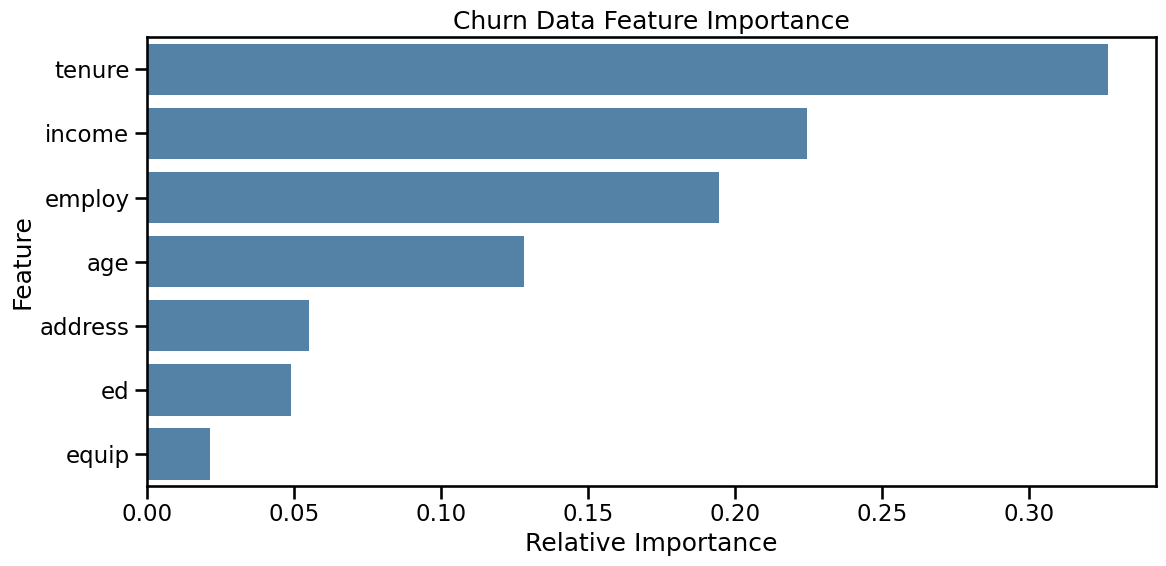

In [23]:
feature_imp = pd.Series(ada_churn.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=ax, color='steelblue')
ax.set(title='Churn Data Feature Importance', xlabel='Relative Importance', ylabel='Feature')
plt.tight_layout()
plt.show()


**Findings:**

The most important churn feature is **tenure**. **Income** and **employment length** are the next most important features. This means the AdaBoost model relies mostly on how long the customer has stayed, their income, and their work history when predicting churn.


We see that adding more weak classifiers causes overfitting. We can verify by plotting the training and test accuracy over the number of classifiers:


100%|██████████| 20/20 [00:48<00:00,  2.42s/it]


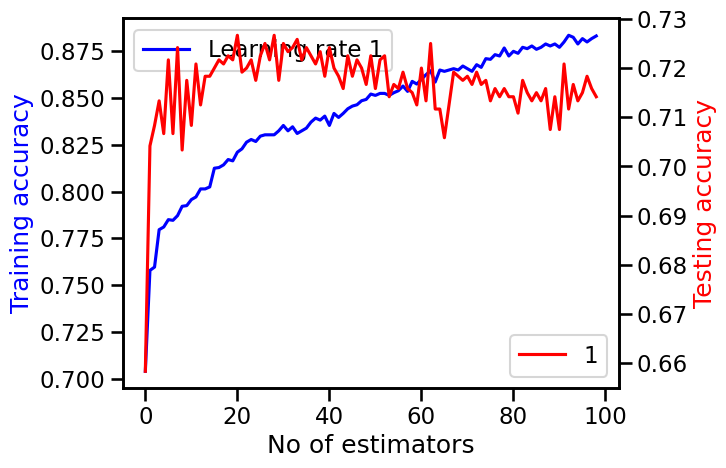

In [24]:
get_accuracy_bag(X,
                 y,
                 title="Training and Test Accuracy vs Weak Classifiers",
                 Learning_rate_=[1],
                 times=20,
                 xlabel='Number Estimators')

As you can see, as the number of classifiers increases so does the overfitting; the training accuracy increases and conversely, the testing accuracy decreases. One way to decrease overfitting is using the learning rate <code>learning_rate</code> with a default value of 1. This is a type of Regularization. For more detail on Regularization, check out <a href="https://hastie.su.domains/Papers/ESLII.pdf?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML241ENSkillsNetwork31576874-2022-01-01#page=383">here</a>.


In [25]:
n_estimators=100
random_state=0
learning_rate=0.7

We can now train the model, make a prediction, and calculate the accuracy. We see that by increasing the learning rate the test accuracy has improved.


In [26]:
model = AdaBoostClassifier(n_estimators=n_estimators,random_state=random_state,learning_rate=learning_rate)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(get_accuracy(X_train, X_test, y_train, y_test, model))

{'test Accuracy': 0.7, 'train Accuracy': 0.7928571428571428}


Compared to the previous results we see the model does better on the test data. We can try different learning rates using the method <code>get_accuracy_bag</code>. In this case, the learning rates are 0.2,0.4,0.6, and 1. As the learning rate goes down we see that the testing accuracy increases while conversely, the training accuracy decreases .


100%|██████████| 20/20 [03:13<00:00,  9.69s/it]


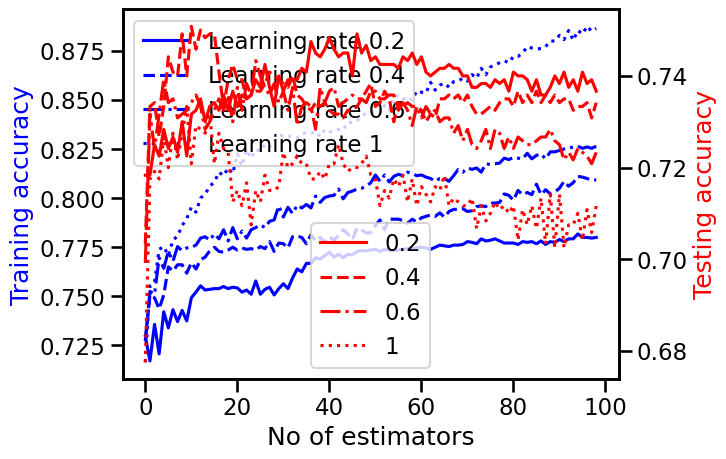

In [27]:
get_accuracy_bag(X,
                 y,
                 title="Training and Test Accuracy vs Weak Classifiers",
                 Learning_rate_=[0.2,0.4,0.6,1],
                 times=20,
                 xlabel='Number Estimators')

Another important parameter is <code>algorithm</code> with takes on the values <code>SAMME</code>, <code>SAMME.R</code>. The default is  <code>’SAMME.R’</code>. The <code>SAMME.R</code> algorithm typically converges faster than <code>SAMME</code>, achieving a lower test error with fewer boosting iterations. For more details, check <a href="https://hastie.su.domains/Papers/samme.pdf?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML241ENSkillsNetwork31576874-2022-01-01">the paper</a>. One issue is that <code>SAMME.R</code> can't be used all the time as we will need the Base classifier to generate the probability of belonging to each class.


#### **Changing the Base Classifier**


AdaBoost is usually performed with Decision Trees but we can use other base classifiers. However, if the classifier is too strong it will cause overfitting. Consider using the following Support Vector Machine (SVM) as the base classifier:


In [28]:
from sklearn.svm import SVC

In [29]:
base_estimator=SVC(kernel='rbf',gamma=1)

We see the SVM does extremely well:


In [30]:
base_estimator.fit(X_train, y_train)

print(get_accuracy(X_train, X_test, y_train, y_test, base_estimator))

{'test Accuracy': 0.7166666666666667, 'train Accuracy': 1.0}


The Base classifier for SVM can not generate the probability of belonging to each class. If you uncomment the following line of code you will get an error.


In [31]:
#base_estimator.predict_proba(X_train)

Therefore the parameter <code>algorithm</code> must be <code>'SAMME'</code>


In [32]:
algorithm='SAMME'

In [33]:
model =AdaBoostClassifier(n_estimators=5, estimator=base_estimator,learning_rate=1,algorithm='SAMME' )

We see the AdaBoost model does worse, this is similar to overfitting. In addition, SVM takes much longer to train than classification trees:


In [34]:
model.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = model.predict(X_test)
print(get_accuracy(X_train, X_test, y_train, y_test, model))

{'test Accuracy': 0.7166666666666667, 'train Accuracy': 0.7071428571428572}


We see that each tree in RF is less correlated than Bagging:


### **Cancer Data Example**

The same cancer dataset is used for the tree-based methods in notebooks 3.5.1 to 3.5.4.

Let's load the dataset:


In [35]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/cell_samples.csv")

df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


Now lets remove rows that have a ? in the <code>BareNuc</code> column:


In [36]:
df= df[pd.to_numeric(df['BareNuc'], errors='coerce').notnull()]

We obtain the features:


In [37]:
X =  df[['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc', 'BlandChrom', 'NormNucl', 'Mit']]

X.head()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit
0,5,1,1,1,2,1,3,1,1
1,5,4,4,5,7,10,3,2,1
2,3,1,1,1,2,2,3,1,1
3,6,8,8,1,3,4,3,7,1
4,4,1,1,3,2,1,3,1,1


We obtain the class labels:


In [38]:
y=df['Class']
y.head()

0    2
1    2
2    2
3    2
4    2
Name: Class, dtype: int64

We split the data into training and testing sets.


In [39]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4, stratify=y)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (546, 9) (546,)
Test set: (137, 9) (137,)


We use <code>GridSearchCV</code> to search over specified parameter values of the model. Because this is a classification problem, we use <code>StratifiedKFold</code> for cross-validation. It shuffles the data before making the folds and keeps the class proportions similar in each fold.


In [40]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

We create a <code>AdaBoost</code> object and list the parameters using the method <code>get_params()</code>:


In [41]:
model = AdaBoostClassifier()
model.get_params().keys()

dict_keys(['algorithm', 'estimator', 'learning_rate', 'n_estimators', 'random_state'])

We can use GridSearch for Exhaustive search over specified parameter values. We see many of the parameters are similar to Classification trees; let's try different parameters for <code>learning_rate</code>, <code>n_estimators</code>, and <code>algorithm</code>.


In [42]:
param_grid = {'learning_rate': [0.1*(n+1) for n in range(10)],
             'n_estimators' : [2*n+1 for n in range(10)],
              'algorithm':['SAMME', 'SAMME.R']}                

param_grid 

{'learning_rate': [0.1,
  0.2,
  0.30000000000000004,
  0.4,
  0.5,
  0.6000000000000001,
  0.7000000000000001,
  0.8,
  0.9,
  1.0],
 'n_estimators': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 'algorithm': ['SAMME', 'SAMME.R']}

We create the Grid Search object and fit it:


In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)
search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=cv)
search.fit(X_train, y_train)

,estimator,AdaBoostClassifier()
,param_grid,"{'algorithm': ['SAMME', 'SAMME.R'], 'learning_rate': [0.1, 0.2, ...], 'n_estimators': [1, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


We can see the best accuracy score of the searched parameters was \~96%.


In [44]:
search.best_score_

0.9724937447873228

The best parameter values are:


In [45]:
search.best_params_

{'algorithm': 'SAMME', 'learning_rate': 0.2, 'n_estimators': 9}

We can calculate accuracy on the test data using the test data:


In [46]:

print(get_accuracy(X_train, X_test, y_train, y_test, search.best_estimator_))

{'test Accuracy': 0.948905109489051, 'train Accuracy': 0.9706959706959707}


#### **Evaluation**

Evaluate the best AdaBoost model from GridSearchCV using a confusion matrix, ROC curve, and precision-recall curve.


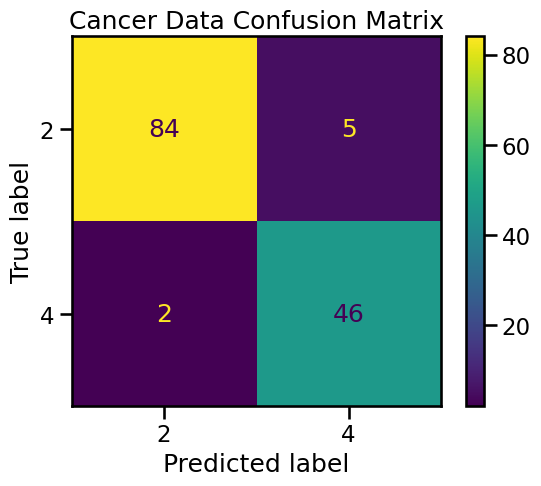

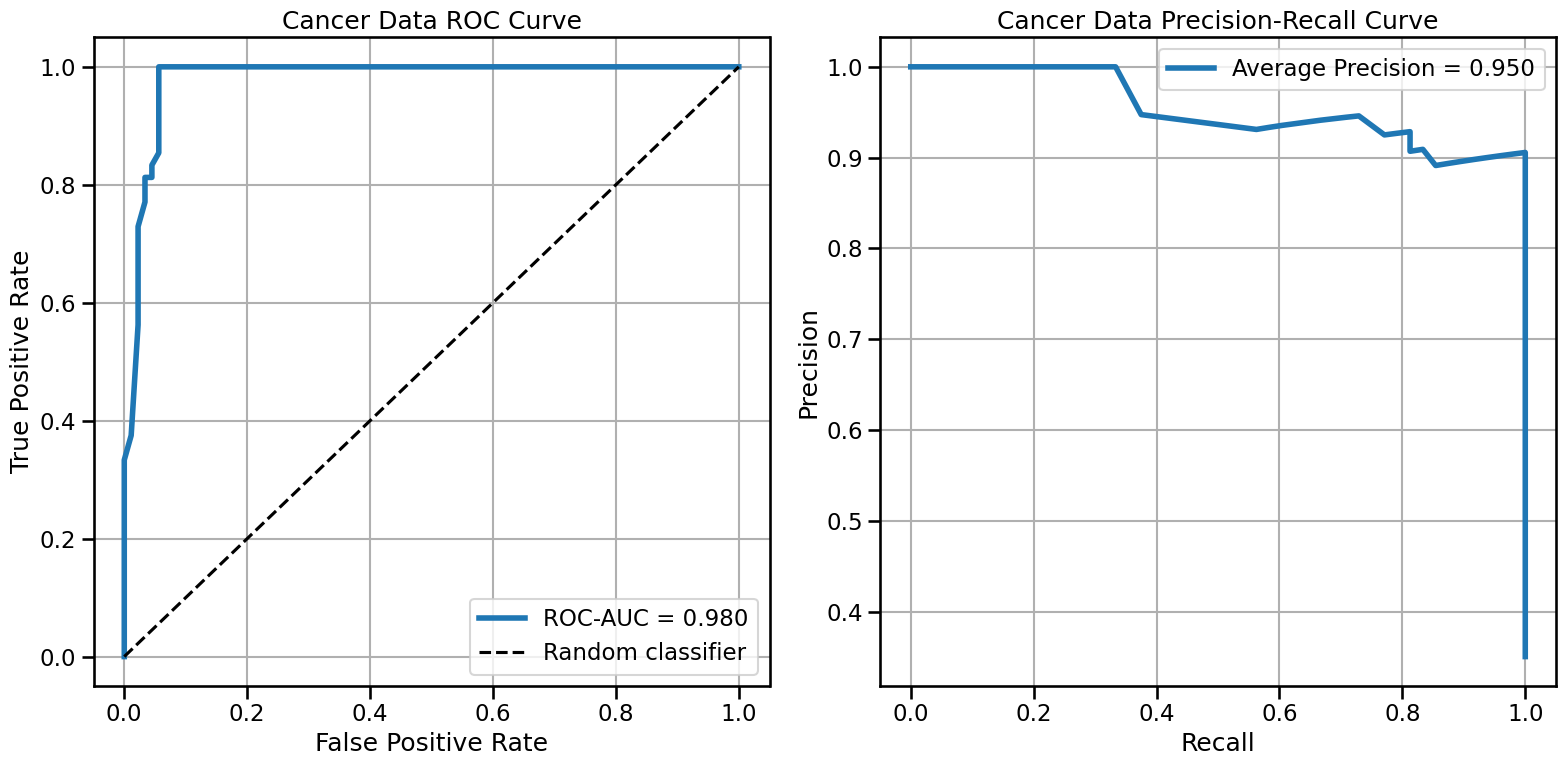

In [47]:
ada_cancer = search.best_estimator_
y_pred = ada_cancer.predict(X_test)

sns.set_context('talk')
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ada_cancer.classes_)
disp.plot()
plt.title('Cancer Data Confusion Matrix')
plt.show()

# In this dataset, class 4 represents malignant samples.
positive_class = 4
y_score = ada_cancer.predict_proba(X_test)[:, list(ada_cancer.classes_).index(positive_class)]
y_test_binary = (y_test == positive_class).astype(int)

fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

fpr, tpr, _ = metrics.roc_curve(y_test_binary, y_score)
roc_auc = metrics.roc_auc_score(y_test_binary, y_score)
axes[0].plot(fpr, tpr, linewidth=4, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='black', label='Random classifier')
axes[0].set(title='Cancer Data ROC Curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[0].legend()
axes[0].grid(True)

precision, recall, _ = metrics.precision_recall_curve(y_test_binary, y_score)
avg_precision = metrics.average_precision_score(y_test_binary, y_score)
axes[1].plot(recall, precision, linewidth=4, label=f'Average Precision = {avg_precision:.3f}')
axes[1].set(title='Cancer Data Precision-Recall Curve', xlabel='Recall', ylabel='Precision')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


**Findings:**

The tuned AdaBoost cancer model performs well, with **0.949 test accuracy** and **0.971 training accuracy**. The confusion matrix shows only a few mistakes: **5 benign samples were predicted as malignant**, and **2 malignant samples were predicted as benign**. The ROC-AUC is about **0.980**, which shows that the model separates benign and malignant samples well.


#### **Feature Importance**

Plot the cell features that contribute most to the best AdaBoost model.


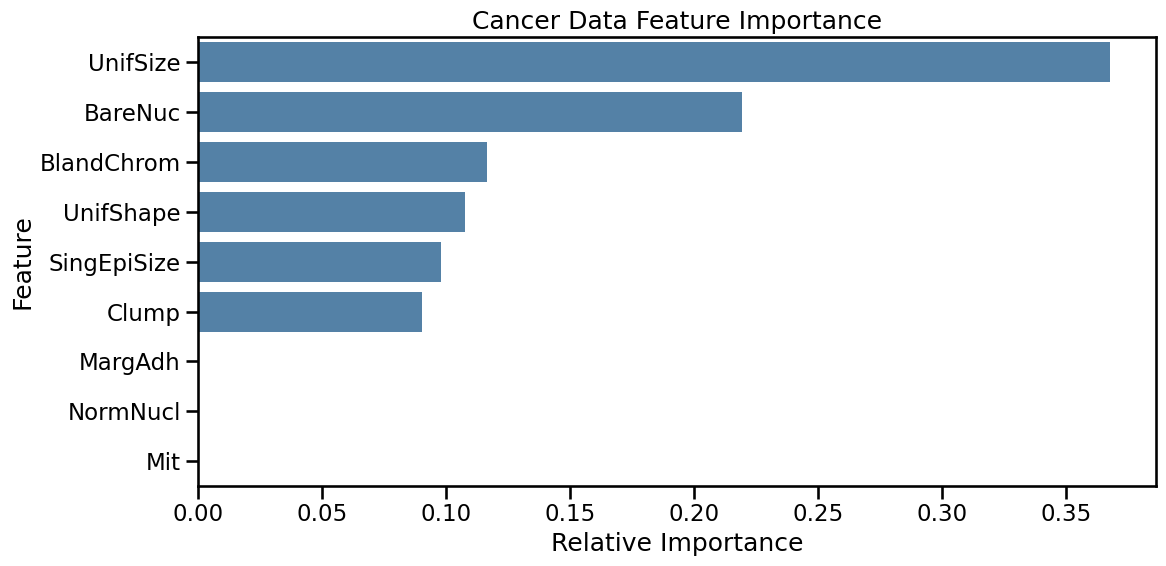

In [48]:
feature_imp = pd.Series(ada_cancer.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=ax, color='steelblue')
ax.set(title='Cancer Data Feature Importance', xlabel='Relative Importance', ylabel='Feature')
plt.tight_layout()
plt.show()


**Findings:**

The most important cancer feature is **Uniformity of Cell Size**. **Bare Nuclei**, **Bland Chromatin**, and **Uniformity of Cell Shape** are also important. These results show that AdaBoost mainly uses cell size, nuclei, and cell-shape patterns to classify the cancer samples.


### **Exercise: Course of Treatment Data**

The same course of treatment dataset is used for the tree-based methods in notebooks 3.5.1 to 3.5.5.


In [49]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv", delimiter=",")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


Let's create the X and y for our dataset:


In [50]:
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values
X[0:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [51]:
y = df["Drug"]
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

Now lets use a <code>LabelEncoder</code> to turn categorical features into numerical:


In [52]:
from sklearn import preprocessing
le_sex = preprocessing.LabelEncoder()
le_sex.fit(['F','M'])
X[:,1] = le_sex.transform(X[:,1]) 


le_BP = preprocessing.LabelEncoder()
le_BP.fit([ 'LOW', 'NORMAL', 'HIGH'])
X[:,2] = le_BP.transform(X[:,2])


le_Chol = preprocessing.LabelEncoder()
le_Chol.fit([ 'NORMAL', 'HIGH'])
X[:,3] = le_Chol.transform(X[:,3]) 

X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

Split the data into training and testing data with a 80/20 split.


In [53]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4, stratify=y)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (160, 5) (160,)
Test set: (40, 5) (40,)


We can use GridSearch for Exhaustive search over specified parameter values.


In [54]:
param_grid = {'learning_rate': [0.1*(n+1) for n in range(10)],
             'n_estimators' : [2*n+1 for n in range(10)],
              'algorithm':['SAMME', 'SAMME.R']}                

param_grid 


{'learning_rate': [0.1,
  0.2,
  0.30000000000000004,
  0.4,
  0.5,
  0.6000000000000001,
  0.7000000000000001,
  0.8,
  0.9,
  1.0],
 'n_estimators': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 'algorithm': ['SAMME', 'SAMME.R']}

Create a <code>AdaBoostClassifier</code> object called <code>model</code> :


In [55]:
model = AdaBoostClassifier()


Create a <code>StratifiedKFold</code> object called <code>cv</code>. Then create a <code>GridSearchCV</code> object called <code>search</code> with <code>estimator</code> set to <code>model</code>, <code>param_grid</code> set to <code>param_grid</code>, <code>scoring</code> set to <code>accuracy</code>, and <code>cv</code> set to <code>cv</code>. Fit the <code>GridSearchCV</code> object to <code>X_train</code> and <code>y_train</code>.


In [56]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)
search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=cv)
search.fit(X_train, y_train)

,estimator,AdaBoostClassifier()
,param_grid,"{'algorithm': ['SAMME', 'SAMME.R'], 'learning_rate': [0.1, 0.2, ...], 'n_estimators': [1, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


We can find the accuracy of the best model.


In [57]:
search.best_score_

0.8375

We can find the best parameter values:


In [58]:
search.best_params_

{'algorithm': 'SAMME',
 'learning_rate': 0.30000000000000004,
 'n_estimators': 17}

We can find the accuracy test data:


In [59]:
print(get_accuracy(X_train, X_test, y_train, y_test, search.best_estimator_))

{'test Accuracy': 0.8, 'train Accuracy': 0.80625}


#### **Evaluation**

Evaluate the best AdaBoost model from GridSearchCV using a confusion matrix and one-vs-rest ROC/precision-recall curves.


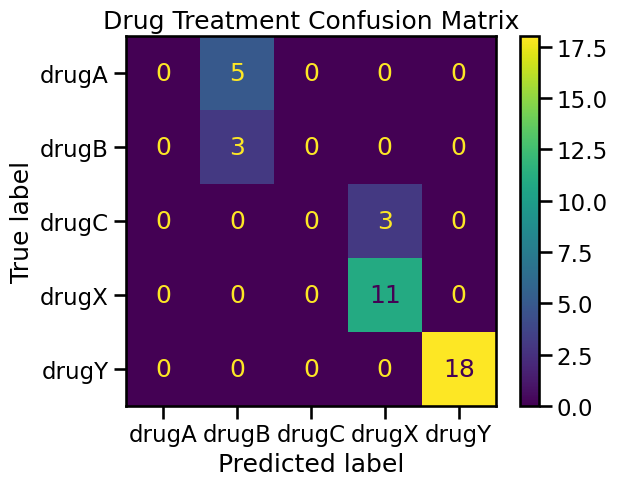

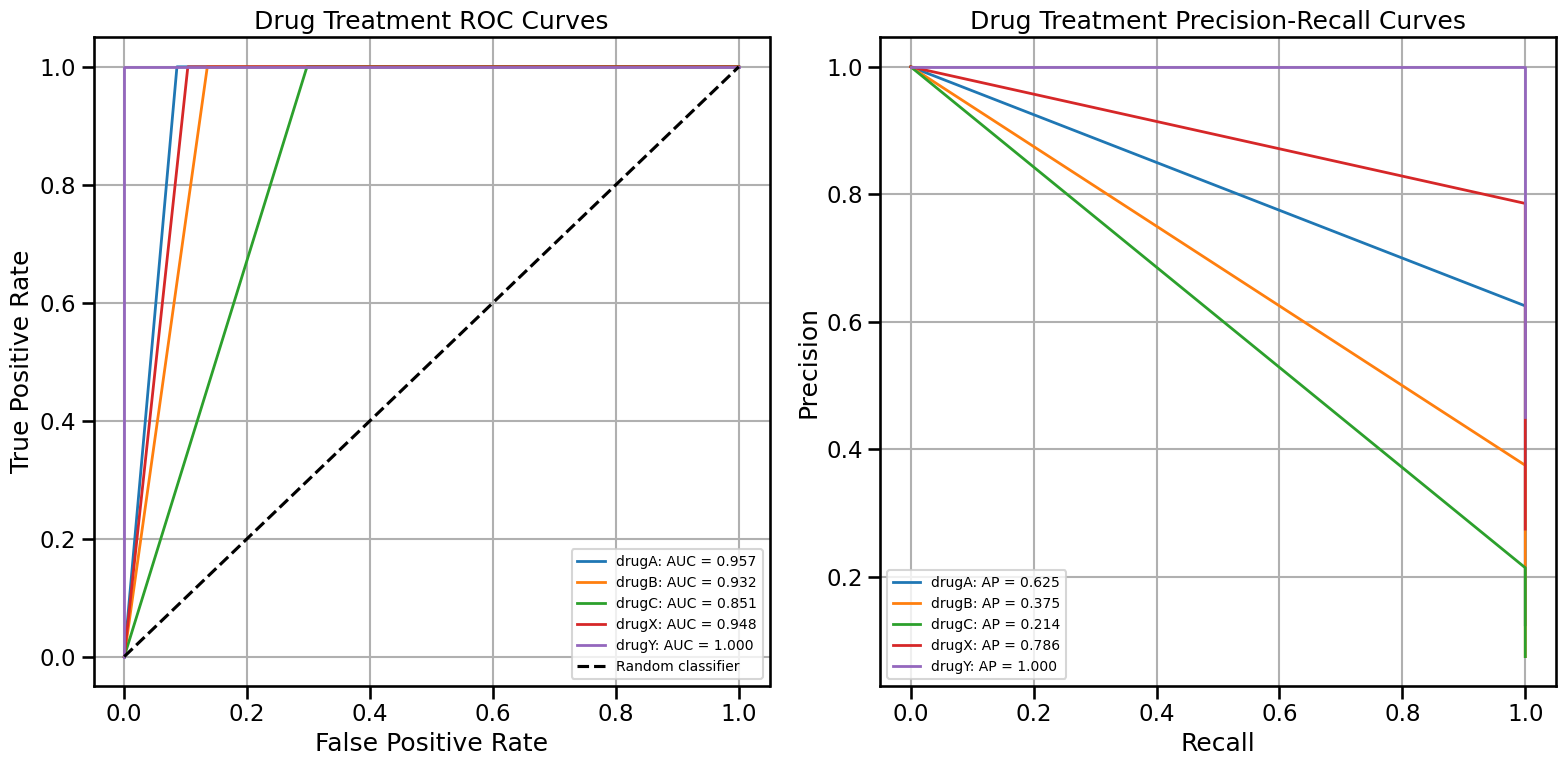

In [60]:
ada_drug = search.best_estimator_
y_pred = ada_drug.predict(X_test)

sns.set_context('talk')
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ada_drug.classes_)
disp.plot()
plt.title('Drug Treatment Confusion Matrix')
plt.show()

classes = ada_drug.classes_
y_score = ada_drug.predict_proba(X_test)
y_test_binary = pd.get_dummies(pd.Categorical(y_test, categories=classes))

fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = metrics.roc_curve(y_test_binary.iloc[:, i], y_score[:, i])
    roc_auc = metrics.roc_auc_score(y_test_binary.iloc[:, i], y_score[:, i])
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{class_name}: AUC = {roc_auc:.3f}')

    precision, recall, _ = metrics.precision_recall_curve(y_test_binary.iloc[:, i], y_score[:, i])
    avg_precision = metrics.average_precision_score(y_test_binary.iloc[:, i], y_score[:, i])
    axes[1].plot(recall, precision, linewidth=2, label=f'{class_name}: AP = {avg_precision:.3f}')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='black', label='Random classifier')
axes[0].set(title='Drug Treatment ROC Curves', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[0].legend(fontsize=10)
axes[0].grid(True)

axes[1].set(title='Drug Treatment Precision-Recall Curves', xlabel='Recall', ylabel='Precision')
axes[1].legend(fontsize=10)
axes[1].grid(True)

plt.tight_layout()
plt.show()


**Findings:**

The tuned AdaBoost drug model reaches **0.80 test accuracy** and **0.806 training accuracy**. The similar train and test scores suggest little overfitting. The confusion matrix shows that the model correctly classifies all **drugB**, **drugX**, and **drugY** test cases, but it misclassifies all **drugA** cases as **drugB** and all **drugC** cases as **drugX**. This means the model performs well for some drug classes but struggles with smaller classes.


#### **Feature Importance**

Plot the patient features that contribute most to the best AdaBoost model.


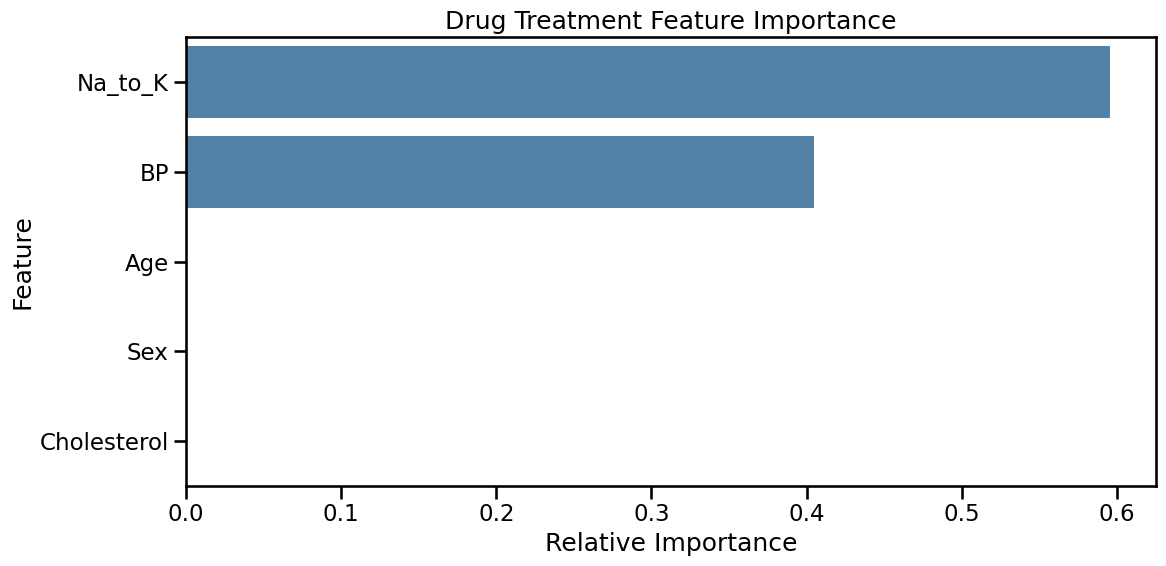

In [61]:
feature_names = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
feature_imp = pd.Series(ada_drug.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=ax, color='steelblue')
ax.set(title='Drug Treatment Feature Importance', xlabel='Relative Importance', ylabel='Feature')
plt.tight_layout()
plt.show()


**Findings:**

The drug treatment feature-importance plot shows that AdaBoost uses only **Na_to_K** and **Blood Pressure** in this fitted model. **Na_to_K** is the strongest feature, followed by **Blood Pressure**. **Age**, **Sex**, and **Cholesterol** have zero importance here, so they did not help this AdaBoost model make its final predictions.


## **Author**

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a>, Su Wu

### **Other Contributors**

<a href="https://www.linkedin.com/in/richard-ye/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Richard Ye</a>

## <h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>

<!--## Change Log

| Date (YYYY-MM-DD)                                                         | Version | Changed By           | Change Description   |
| ------------------------------------------------------------------------- | ------- | -------------------- | -------------------- |
| 2020-11-27                                                                | 0.1     | Joseph Santarcangelo | Created Lab Template |
| 2022-2-8                                                                  | 0.2     | Steve Hord           | QA pass              |
| 2022-05-03                                                                | 0.3     | Richard Ye           | Fixed spelling/HTML  |--!>


